# Stage 4 — Full Pipeline Demo

בשלב הזה נחבר את כל חלקי הפרויקט לפייפליין אחד מלא:

1. קבלת תמונת שעון דיגיטלי  
2. קריאת השעה באמצעות המודל של Stage 2  
3. קבלת תמונת שעון אנלוגי עם מחוגים  
4. ניקוי המחוגים באמצעות המודל של Stage 3  
5. ציור מחוגים חדשים לפי השעה שנקראה מהשעון הדיגיטלי  
6. הצגת התוצאה הסופית

In [1]:
import math
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms, models

## הגדרות בסיס ונתיבים

כאן נגדיר את נתיבי הדאטה והמודלים ששמרנו בשלבים הקודמים.

In [2]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"

LABELS_PATH = DATA_DIR / "labels.csv"

DIGITAL_MODEL_PATH = MODELS_DIR / "digital_time_reader.pth"
ANALOG_CLEANER_MODEL_PATH = MODELS_DIR / "analog_cleaner_autoencoder.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Using device:", DEVICE)
print("Labels exists:", LABELS_PATH.exists())
print("Digital model exists:", DIGITAL_MODEL_PATH.exists())
print("Analog cleaner model exists:", ANALOG_CLEANER_MODEL_PATH.exists())

Using device: cpu
Labels exists: True
Digital model exists: True
Analog cleaner model exists: True


## הגדרת מודל קריאת השעון הדיגיטלי

נגדיר מחדש את אותה ארכיטקטורה שאימנו ב־Stage 2, ואז נטען אליה את המשקלים השמורים.

In [3]:
class DigitalTimeReader(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained=False)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.hour_head = nn.Linear(num_features, 24)
        self.minute_head = nn.Linear(num_features, 60)
        self.second_head = nn.Linear(num_features, 60)

    def forward(self, x):
        features = self.backbone(x)

        hour_pred = self.hour_head(features)
        minute_pred = self.minute_head(features)
        second_pred = self.second_head(features)

        return hour_pred, minute_pred, second_pred

In [6]:
digital_model = DigitalTimeReader().to(DEVICE)
digital_model.load_state_dict(torch.load(DIGITAL_MODEL_PATH, map_location=DEVICE))
digital_model.eval()

print("Digital reader loaded successfully")


Digital reader loaded successfully


## הגדרת מודל ניקוי השעון האנלוגי

נגדיר מחדש את אותו AutoEncoder שאימנו ב־Stage 3, ואז נטען את המשקלים השמורים.

In [7]:
class AnalogCleanerAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
analog_cleaner = AnalogCleanerAutoEncoder().to(DEVICE)
analog_cleaner.load_state_dict(torch.load(ANALOG_CLEANER_MODEL_PATH, map_location=DEVICE))
analog_cleaner.eval()

print("Analog cleaner loaded successfully")

Analog cleaner loaded successfully


## פונקציה לקריאת השעה מהשעון הדיגיטלי

הפונקציה תקבל תמונת שעון דיגיטלי, תעביר אותה למודל, ותחזיר:

- hour
- minute
- second

In [9]:
def predict_digital_time(image):
    digital_model.eval()

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_hour, pred_minute, pred_second = digital_model(input_tensor)

    hour = torch.argmax(pred_hour, dim=1).item()
    minute = torch.argmax(pred_minute, dim=1).item()
    second = torch.argmax(pred_second, dim=1).item()

    return hour, minute, second

## פונקציה לניקוי השעון האנלוגי

הפונקציה תקבל תמונת שעון אנלוגי עם מחוגים, ותשתמש במודל כדי להחזיר תמונה נקייה בלי מחוגים.

In [11]:
def tensor_to_pil(tensor):
    tensor = tensor.detach().cpu()
    tensor = torch.clamp(tensor, 0, 1)
    tensor = tensor.squeeze(0)
    tensor = tensor.permute(1, 2, 0).numpy()
    tensor = (tensor * 255).astype(np.uint8)
    return Image.fromarray(tensor)


def clean_analog_clock(image):
    analog_cleaner.eval()

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output_tensor = analog_cleaner(input_tensor)

    cleaned_image = tensor_to_pil(output_tensor)

    return cleaned_image

## פונקציה לציור מחוגים חדשים

לאחר שנקבל את השעה מהמודל הדיגיטלי, נצייר מחוגי שעה, דקה ושנייה על השעון האנלוגי הנקי.

החישוב מבוסס על זוויות:

- שעה: כל שעה = 30 מעלות
- דקה: כל דקה = 6 מעלות
- שנייה: כל שנייה = 6 מעלות


In [12]:
def draw_hand(draw, center, angle_deg, length, color, width):
    cx, cy = center
    angle = math.radians(angle_deg - 90)

    x = cx + length * math.cos(angle)
    y = cy + length * math.sin(angle)

    draw.line([cx, cy, x, y], fill=color, width=width)


def draw_new_hands_on_clock(clean_clock_image, hour, minute, second):
    img = clean_clock_image.copy()
    draw = ImageDraw.Draw(img)

    image_size = img.size[0]
    center = (image_size // 2, image_size // 2)

    hour_angle = ((hour % 12) + minute / 60) * 30
    minute_angle = (minute + second / 60) * 6
    second_angle = second * 6

    draw_hand(draw, center, hour_angle, 45, (20, 20, 20), 6)
    draw_hand(draw, center, minute_angle, 65, (20, 20, 20), 4)
    draw_hand(draw, center, second_angle, 75, (200, 0, 0), 2)

    cx, cy = center
    draw.ellipse([cx - 5, cy - 5, cx + 5, cy + 5], fill=(20, 20, 20))

    return img

## טעינת דוגמה מהדאטה

נבחר דוגמה אקראית מהדאטה:

- תמונה דיגיטלית — ממנה נקרא את השעה
- תמונה אנלוגית עם מחוגים — אותה ננקה ונחליף לה את המחוגים

In [20]:
df = pd.read_csv(LABELS_PATH)

# choose digital input and analog input from different samples
digital_sample = df.sample(1, random_state=None).iloc[0]
analog_sample = df.sample(1, random_state=None).iloc[0]

while analog_sample["sample_id"] == digital_sample["sample_id"]:
    analog_sample = df.sample(1, random_state=None).iloc[0]

digital_image = Image.open(digital_sample["digital_image_path"]).convert("RGB")
analog_image = Image.open(analog_sample["analog_with_hands_path"]).convert("RGB")

digital_hour = int(digital_sample["hour"])
digital_minute = int(digital_sample["minute"])
digital_second = int(digital_sample["second"])

analog_hour = int(analog_sample["hour"])
analog_minute = int(analog_sample["minute"])
analog_second = int(analog_sample["second"])

print(f"Digital input time: {digital_hour:02d}:{digital_minute:02d}:{digital_second:02d}")
print(f"Analog input time:  {analog_hour:02d}:{analog_minute:02d}:{analog_second:02d}")

Digital input time: 07:03:43
Analog input time:  14:44:46


הרצת פייפליין מלא


In [21]:
import time

start_time = time.time()

pred_hour, pred_minute, pred_second = predict_digital_time(digital_image)

cleaned_analog = clean_analog_clock(analog_image)

final_output = draw_new_hands_on_clock(
    cleaned_analog,
    pred_hour,
    pred_minute,
    pred_second
)

end_time = time.time()
runtime_seconds = end_time - start_time

print(f"Digital true time:      {digital_hour:02d}:{digital_minute:02d}:{digital_second:02d}")
print(f"Analog original time:   {analog_hour:02d}:{analog_minute:02d}:{analog_second:02d}")
print(f"Predicted digital time: {pred_hour:02d}:{pred_minute:02d}:{pred_second:02d}")
print(f"Pipeline runtime:       {runtime_seconds:.4f} seconds")

Digital true time:      07:03:43
Analog original time:   14:44:46
Predicted digital time: 07:03:43
Pipeline runtime:       0.2972 seconds


## הצגת התוצאה

נציג:

- השעון הדיגיטלי המקורי  
- השעון האנלוגי המקורי  
- השעון לאחר ניקוי המחוגים  
- הפלט הסופי עם המחוגים החדשים

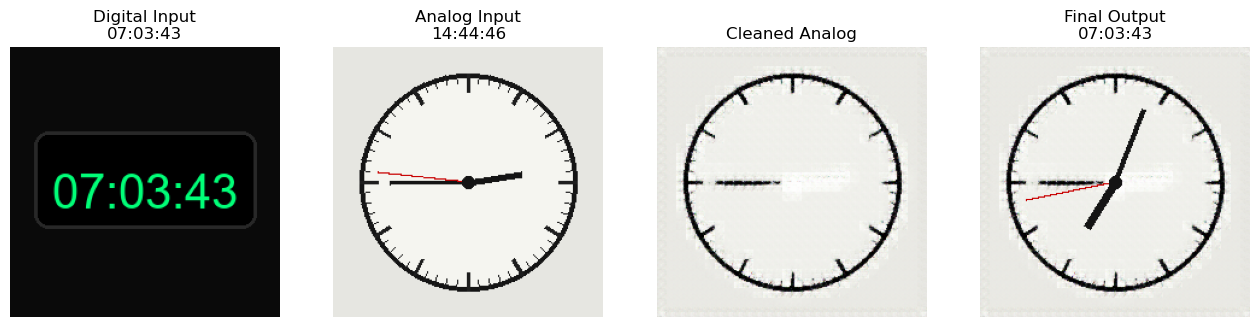

In [22]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(digital_image)
plt.title(f"Digital Input\n{digital_hour:02d}:{digital_minute:02d}:{digital_second:02d}")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(analog_image)
plt.title(f"Analog Input\n{analog_hour:02d}:{analog_minute:02d}:{analog_second:02d}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cleaned_analog)
plt.title("Cleaned Analog")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(final_output)
plt.title(f"Final Output\n{pred_hour:02d}:{pred_minute:02d}:{pred_second:02d}")
plt.axis("off")

plt.show()